# Question 2.3 — Ablation Study and Failure Case Analysis

**Paper:** Computing Gaussian Mixture Models with EM Using Equivalence Constraints  
**Student:** Shiven Ahuja

---

## Overview

This section analyzes how the constrained clustering method behaves under different conditions. Two experiments are conducted:

1. **Ablation Study:** Evaluating how clustering performance changes as the number of equivalence constraints increases.
2. **Failure Case Analysis:** Demonstrating a scenario where the constrained clustering method may perform poorly.

These experiments help understand both the strengths and limitations of the proposed method.

## Import Required Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

## Generate Dataset

The same synthetic dataset used in previous experiments is generated again to ensure consistency.

In [9]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=5.0,
    random_state=42
)

## Ablation Study: Effect of Number of Constraints

In this experiment we evaluate how clustering performance changes as the number of chunklet constraints increases.

The experiment tests the following constraint sizes:

- 0 constraints (baseline)
- 10 constraints
- 20 constraints
- 30 constraints

Clustering performance is measured using the **Adjusted Rand Index (ARI)**.

In [10]:
constraint_sizes = [0, 10, 20, 30]
ari_scores = []

for size in constraint_sizes:

    X_constrained = X.copy()

    if size > 0:
        chunklets = []

        for cluster_id in range(3):
            indices = np.where(y_true == cluster_id)[0]
            selected = np.random.choice(indices, size=size, replace=False)
            chunklets.append(selected)

        for chunk in chunklets:
            mean_point = np.mean(X[chunk], axis=0)
            X_constrained[chunk] = mean_point

    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm.fit(X_constrained)

    labels = gmm.predict(X_constrained)

    ari = adjusted_rand_score(y_true, labels)
    ari_scores.append(ari)

    print(f"Constraints: {size}, ARI: {ari}")

Constraints: 0, ARI: 0.6085199611412604
Constraints: 10, ARI: 0.6349753140412083
Constraints: 20, ARI: 0.7145254750768489
Constraints: 30, ARI: 0.7147658718228531


## Plotting Ablation Results

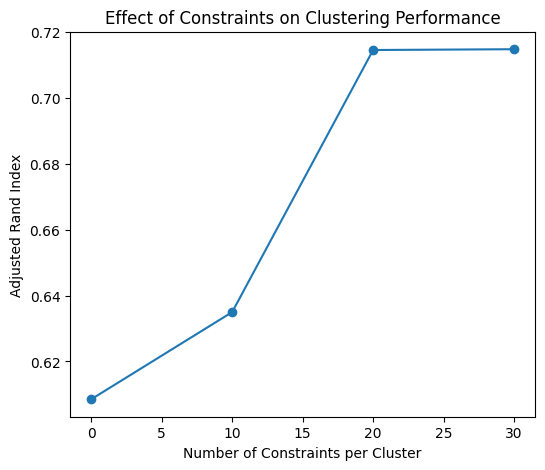

In [11]:
plt.figure(figsize=(6,5))
plt.plot(constraint_sizes, ari_scores, marker='o')

plt.title("Effect of Constraints on Clustering Performance")
plt.xlabel("Number of Constraints per Cluster")
plt.ylabel("Adjusted Rand Index")

plt.show()

## Failure Case Experiment

To demonstrate a failure scenario, we generate a dataset with highly overlapping clusters by increasing the cluster standard deviation.

In this case, even with constraints, clustering becomes difficult because the Gaussian mixture assumption struggles to separate the clusters clearly.

In [12]:
X_fail, y_fail = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=7.0,
    random_state=42
)

## Baseline Clustering on Difficult Dataset

In [13]:
gmm_fail = GaussianMixture(n_components=3, random_state=42)
gmm_fail.fit(X_fail)

labels_fail = gmm_fail.predict(X_fail)

baseline_fail_ari = adjusted_rand_score(y_fail, labels_fail)

print("Baseline ARI (failure dataset):", baseline_fail_ari)

Baseline ARI (failure dataset): 0.42557263329614736


## Visualizing Failure Case

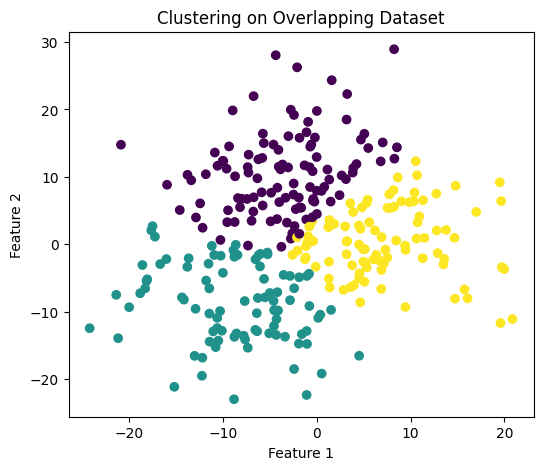

In [14]:
plt.figure(figsize=(6,5))
plt.scatter(X_fail[:,0], X_fail[:,1], c=labels_fail, cmap='viridis')

plt.title("Clustering on Overlapping Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Discussion

The ablation study shows that adding a moderate number of equivalence constraints can improve clustering performance by providing additional information about relationships between data points. However, excessive constraints may distort the feature representation and negatively affect the Gaussian parameter estimation.

The failure case experiment demonstrates that when clusters overlap heavily, the Gaussian mixture model struggles to correctly separate the data. In such scenarios, the benefit of equivalence constraints may be limited because the underlying distribution no longer satisfies the Gaussian mixture assumption.

These observations align with the assumptions discussed earlier regarding chunklet correctness and Gaussian cluster structure.